# LAPORAN TUGAS BESAR STATPROB\n## Modul 2: Analisis Univariat & Profil Karakteristik Penumpang\n**Penanggung Jawab: Andika Pratama**\n*Kelompok: Day in My Anaconda | Dataset: `data/train.csv`*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan data pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Pengaturan estetika grafik matplotlib dan seaborn
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# Palet warna konsisten untuk kelompok kami
WARNA_UTAMA = '#2b5876'
WARNA_KEDUA = '#e74c3c'
WARNA_KETIGA = '#2ecc71'
PALET_KELOMPOK = [WARNA_UTAMA, WARNA_KEDUA, WARNA_KETIGA, '#f39c12', '#9b59b6', '#34495e']
sns.set_palette(PALET_KELOMPOK)

print("Status: Seluruh pustaka berhasil dimuat.")

Status: Seluruh pustaka berhasil dimuat.


In [2]:
# 1. Pemuatan Data Mentah train.csv
# Menghapus kolom 'Unnamed: 0' yang merupakan index sisa saat ekspor berkas csv
train = pd.read_csv('data/train.csv').drop(columns=['Unnamed: 0'], errors='ignore')

print("=== Ringkasan Dimensi & Integritas Data ===")
print(f"Jumlah baris observasi : {train.shape[0]:,} baris")
print(f"Jumlah kolom fitur     : {train.shape[1]} kolom")
print(f"Jumlah baris duplikat  : {train.drop(columns=['id']).duplicated().sum()} baris")
print(f"Jumlah ID duplikat     : {train['id'].duplicated().sum()} ID")

# 2. Pengelompokan Kolom Berdasarkan Sifat Pengukuran
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Membuat representasi target numerik biner (1: satisfied, 0: neutral or dissatisfied)
train["sat"] = (train["satisfaction"] == "satisfied").astype(int)

# 3. Kamus Data & Taksonomi Fitur
kamus_data = pd.DataFrame({
    'Nama Kolom': train.columns,
    'Tipe Data': train.dtypes.values,
    'Kategori Analitis': [
        'Identifier (ID Unik)' if c == 'id' else
        'Target Analisis (Biner)' if c in ['satisfaction', 'sat'] else
        'Kategorikal Nominal Biner' if c in ['Gender', 'Customer Type', 'Type of Travel'] else
        'Kategorikal Ordinal' if c == 'Class' else
        'Skala Rating Layanan (0-5)' if c in rating_cols else
        'Numerik Kontinu/Diskrit' for c in train.columns
    ],
    'Jumlah Nilai Unik': [train[c].nunique() for c in train.columns],
    'Contoh Nilai': [str(train[c].dropna().unique()[:3].tolist()) for c in train.columns]
})
display(kamus_data)

=== Ringkasan Dimensi & Integritas Data ===
Jumlah baris observasi : 103,904 baris
Jumlah kolom fitur     : 24 kolom
Jumlah baris duplikat  : 0 baris
Jumlah ID duplikat     : 0 ID


,Nama Kolom,Tipe Data,Kategori Analitis,Jumlah Nilai Unik,Contoh Nilai
0,id,int64,Identifier (ID Unik),103904,"[70172, 5047, 110028]"
1,Gender,str,Kategorikal Nominal Biner,2,"['Male', 'Female']"
2,Customer Type,str,Kategorikal Nominal Biner,2,"['Loyal Customer', 'disloyal Customer']"
3,Age,int64,Numerik Kontinu/Diskrit,75,"[13, 25, 26]"
4,Type of Travel,str,Kategorikal Nominal Biner,2,"['Personal Travel', 'Business travel']"
5,Class,str,Kategorikal Ordinal,3,"['Eco Plus', 'Business', 'Eco']"
6,Flight Distance,int64,Numerik Kontinu/Diskrit,3802,"[460, 235, 1142]"
7,Inflight wifi service,int64,Skala Rating Layanan (0-5),6,"[3, 2, 4]"
8,Departure/Arrival time convenient,int64,Skala Rating Layanan (0-5),6,"[4, 2, 5]"
9,Ease of Online booking,int64,Skala Rating Layanan (0-5),6,"[3, 2, 5]"


---
## BAB II: ANALISIS UNIVARIAT & PROFIL KARAKTERISTIK PENUMPANG
**Penanggung Jawab Bagian: Andika Pratama**

Pada bagian ini, Andika menganalisis sebaran variabel secara individual: proporsi variabel target kepuasan, karakteristik demografi penumpang (gender, usia, loyalitas), tipe perjalanan, kelas kabin, serta pemetaan skor rata-rata pada 14 aspek layanan maskapai.

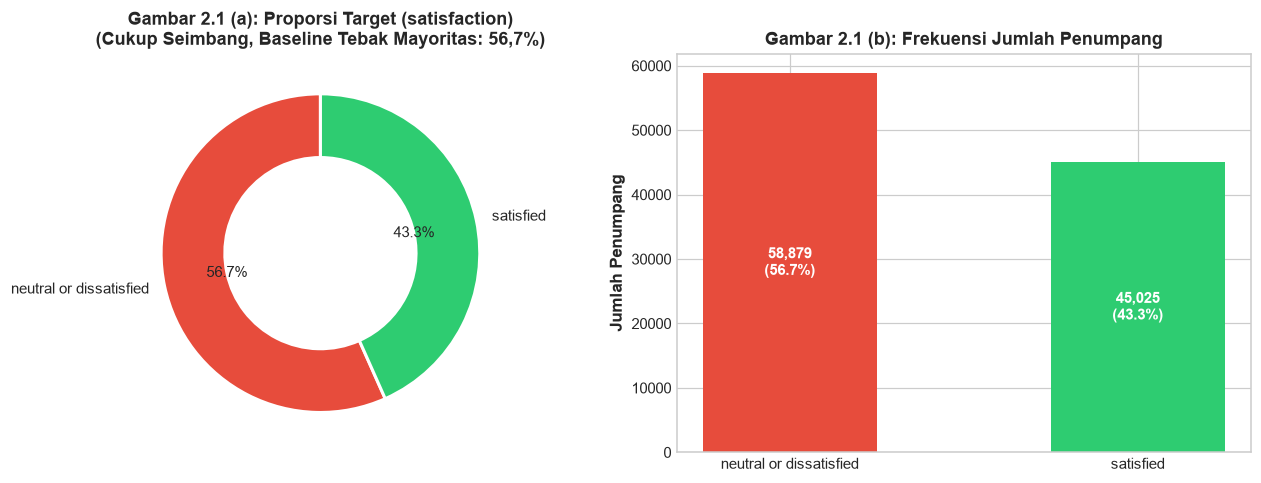

In [3]:
# 1. Analisis Keseimbangan Target Kepuasan
rekap_target = train["satisfaction"].value_counts()
proporsi_target = train["satisfaction"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Donut Chart Target
axes[0].pie(rekap_target, labels=rekap_target.index, autopct='%1.1f%%', startangle=90,
            colors=[WARNA_KEDUA, WARNA_KETIGA], wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[0].set_title("Gambar 2.1 (a): Proporsi Target (satisfaction)\n(Cukup Seimbang, Baseline Tebak Mayoritas: 56,7%)")

# Diagram Batang Frekuensi
batang_target = axes[1].bar(rekap_target.index, rekap_target.values, color=[WARNA_KEDUA, WARNA_KETIGA], width=0.5)
axes[1].set_title("Gambar 2.1 (b): Frekuensi Jumlah Penumpang")
axes[1].set_ylabel("Jumlah Penumpang")
for b in batang_target:
    tinggi = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, tinggi/2, f"{tinggi:,}\n({tinggi/len(train)*100:.1f}%)",
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Distribusi Demografi & Karakteristik Perjalanan Penumpang
Andika memvisualisasikan komposisi profil penumpang berdasarkan jenis kelamin, tipe loyalitas pelanggan, tujuan perjalanan, dan kelas penerbangan.

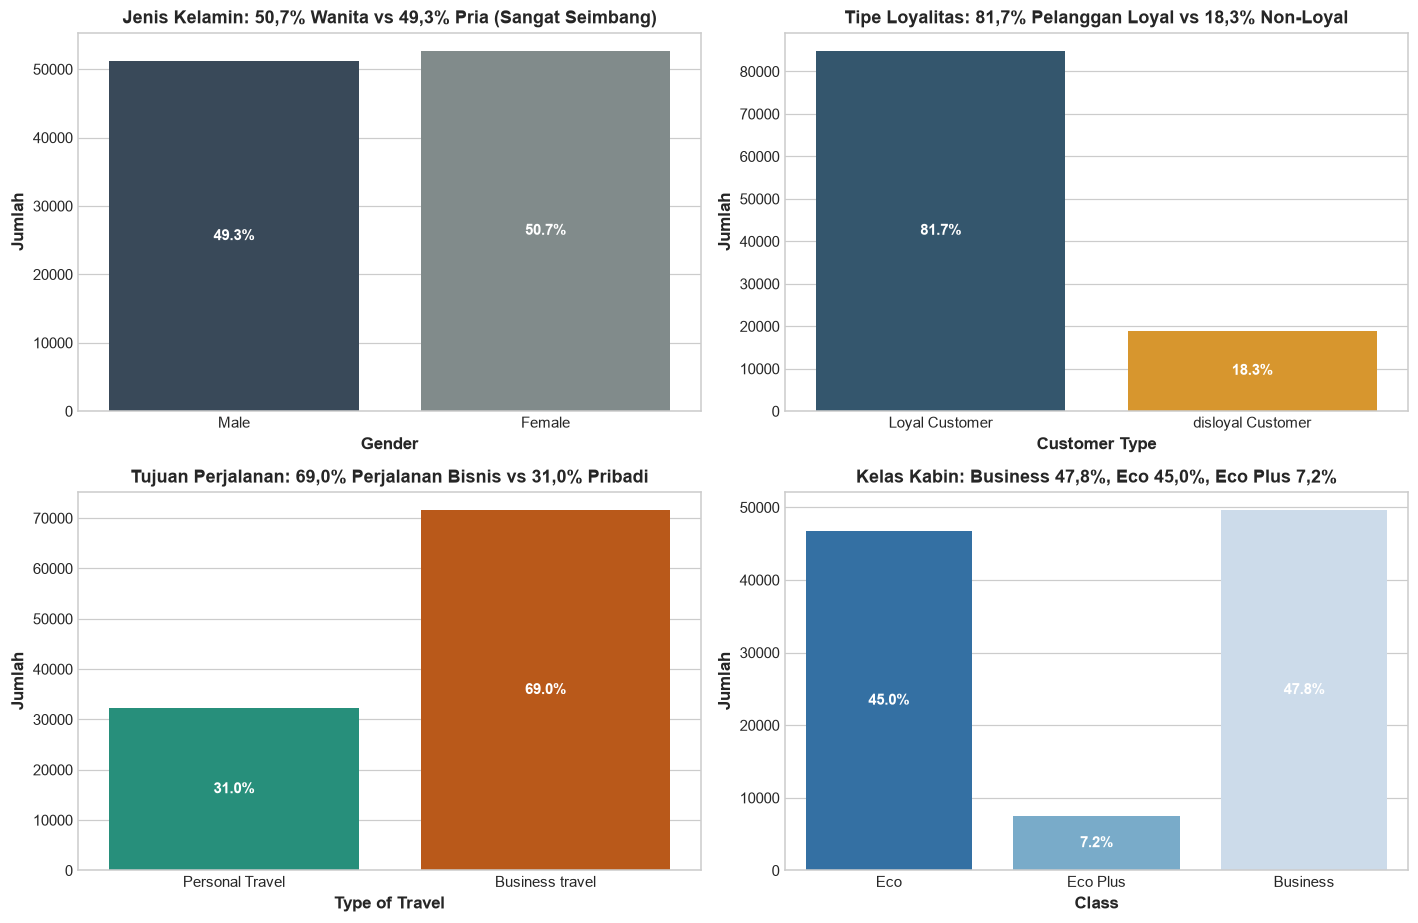

In [4]:
# Gambar 2.2: Distribusi 4 Variabel Kategorikal
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

# 1. Jenis Kelamin (Gender)
sns.countplot(data=train, x="Gender", palette=['#34495e', '#7f8c8d'], ax=axes[0, 0])
axes[0, 0].set_title("Jenis Kelamin: 50,7% Wanita vs 49,3% Pria (Sangat Seimbang)")
axes[0, 0].set_ylabel("Jumlah")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

# 2. Loyalitas Pelanggan (Customer Type)
sns.countplot(data=train, x="Customer Type", palette=[WARNA_UTAMA, '#f39c12'], ax=axes[0, 1])
axes[0, 1].set_title("Tipe Loyalitas: 81,7% Pelanggan Loyal vs 18,3% Non-Loyal")
axes[0, 1].set_ylabel("Jumlah")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

# 3. Tujuan Perjalanan (Type of Travel)
sns.countplot(data=train, x="Type of Travel", palette=['#16a085', '#d35400'], ax=axes[1, 0])
axes[1, 0].set_title("Tujuan Perjalanan: 69,0% Perjalanan Bisnis vs 31,0% Pribadi")
axes[1, 0].set_ylabel("Jumlah")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

# 4. Kelas Penerbangan (Class)
sns.countplot(data=train, x="Class", order=['Eco', 'Eco Plus', 'Business'], palette='Blues_r', ax=axes[1, 1])
axes[1, 1].set_title("Kelas Kabin: Business 47,8%, Eco 45,0%, Eco Plus 7,2%")
axes[1, 1].set_ylabel("Jumlah")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.3 Evaluasi Komparatif Skor Rata-rata 14 Aspek Layanan Maskapai
Andika menghitung skor rata-rata pada skala 1 sampai 5 untuk seluruh fasilitas layanan (di luar nilai rating 0). Fasilitas ini kemudian dikelompokkan menjadi 3 pilar operasional:
1. **Layanan Digital & Bandara** *(Pre-Flight / Digital Touchpoints)*
2. **Kenyamanan & Fasilitas Kabin** *(In-Flight Comfort)*
3. **Pelayanan Awak Pesawat & Bagasi** *(Physical Service)*

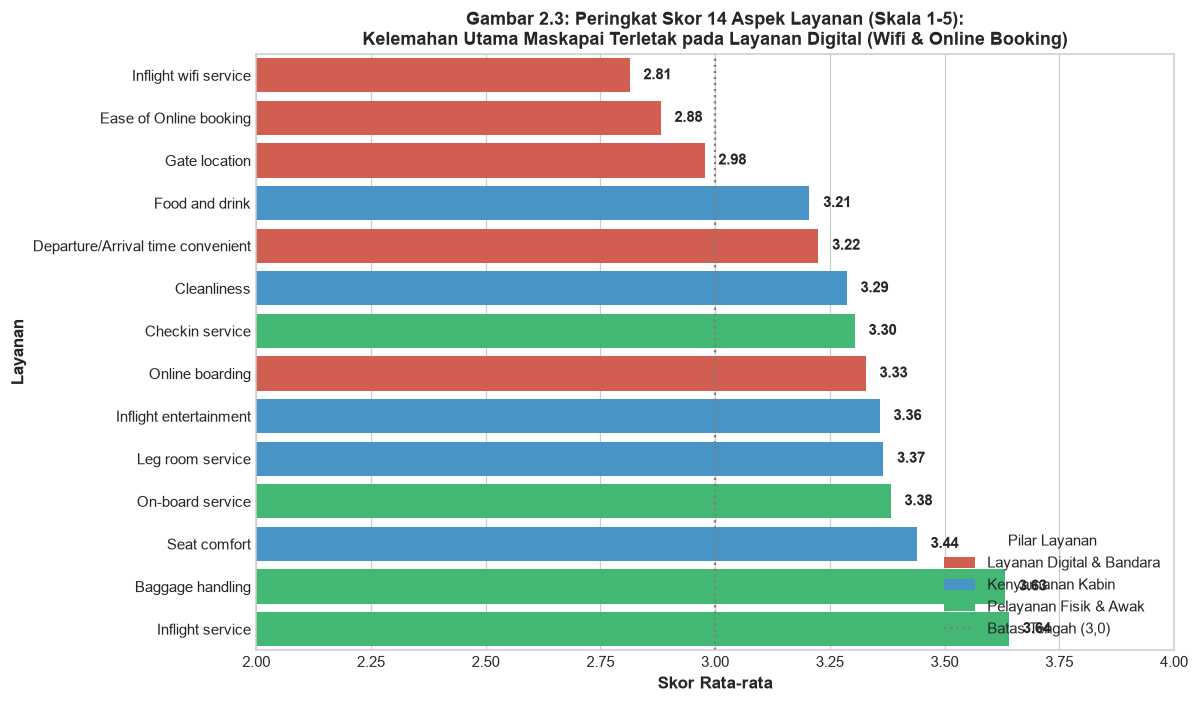

In [5]:
# Pemetaan skor rata-rata berdasarkan kelompok operasional
kategori_layanan = {
    'Inflight wifi service': 'Layanan Digital & Bandara',
    'Ease of Online booking': 'Layanan Digital & Bandara',
    'Online boarding': 'Layanan Digital & Bandara',
    'Gate location': 'Layanan Digital & Bandara',
    'Departure/Arrival time convenient': 'Layanan Digital & Bandara',
    'Seat comfort': 'Kenyamanan Kabin',
    'Leg room service': 'Kenyamanan Kabin',
    'Food and drink': 'Kenyamanan Kabin',
    'Inflight entertainment': 'Kenyamanan Kabin',
    'Cleanliness': 'Kenyamanan Kabin',
    'On-board service': 'Pelayanan Fisik & Awak',
    'Baggage handling': 'Pelayanan Fisik & Awak',
    'Inflight service': 'Pelayanan Fisik & Awak',
    'Checkin service': 'Pelayanan Fisik & Awak'
}

skor_layanan = []
for c, grup in kategori_layanan.items():
    rata_skor = train[train[c] > 0][c].mean()
    skor_layanan.append({'Layanan': c, 'Rata-rata Skor (1-5)': rata_skor, 'Kategori': grup})

df_skor_layanan = pd.DataFrame(skor_layanan).sort_values(by='Rata-rata Skor (1-5)')

plt.figure(figsize=(11, 6.5))
palet_grup = {'Layanan Digital & Bandara': WARNA_KEDUA, 'Kenyamanan Kabin': '#3498db', 'Pelayanan Fisik & Awak': WARNA_KETIGA}
batang_layanan = sns.barplot(data=df_skor_layanan, y='Layanan', x='Rata-rata Skor (1-5)', hue='Kategori', dodge=False, palette=palet_grup)
plt.axvline(3.0, color='gray', linestyle=':', label='Batas Tengah (3,0)')
plt.title("Gambar 2.3: Peringkat Skor 14 Aspek Layanan (Skala 1-5):\nKelemahan Utama Maskapai Terletak pada Layanan Digital (Wifi & Online Booking)")
plt.xlabel("Skor Rata-rata")
plt.xlim(2.0, 4.0)
for p in batang_layanan.patches:
    lebar = p.get_width()
    if lebar > 0:
        plt.annotate(f"{lebar:.2f}", (lebar + 0.03, p.get_y() + p.get_height()/2), va='center', fontweight='bold', fontsize=9.5)
plt.legend(title='Pilar Layanan', loc='lower right')
plt.tight_layout()
plt.show()